# Unrolled QPA Transpilation Scaling (T=2)

Measures how the **2Q depth** and **2Q gate count** of the unrolled QPA circuit (longest-path, static) scale after transpilation.

- Backends compared: `ibm_boston`, `ibm_miami`
- `N = 3, 5, 7, 8` (K=2, T=2)
- For each (backend, N): transpile with 100 different seeds, keep the result with the lowest 2Q depth, also report the average across seeds.

Results are written incrementally to `scaling_results_T2.json` and `scaling_results_T2.csv` so progress survives kernel restarts. Plots are regenerated from these files, so partial runs still render.

In [1]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService

# Make the project-root `core/` and `execution/` packages importable
# (this notebook lives in dynamic_experiment/).
_PROJECT_ROOT = Path.cwd().parent
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

from core.circuit_factory import CircuitFactory

In [2]:
# --- Experiment parameters ---
N_LIST = [3, 5, 7, 9]
K = 2
T = 2                    # n_trials
BACKENDS = ["ibm_boston", "ibm_miami"]
N_SEEDS = 100
OPT_LEVEL = 3
NO_RESET = True          # fresh ancillas per trial (avoids `reset`, which
                         # ibm_miami's target does not advertise as supported)

# --- Persistence paths ---
RESULTS_DIR = Path("scaling_results")
RESULTS_DIR.mkdir(exist_ok=True)
JSON_PATH = RESULTS_DIR / f"scaling_results_T{T}.json"
CSV_PATH  = RESULTS_DIR / f"scaling_results_T{T}.csv"

print(f"Backends : {BACKENDS}")
print(f"N values : {N_LIST}  (K={K}, T={T}, no_reset={NO_RESET})")
print(f"Seeds    : {N_SEEDS} per (backend, N)")
print(f"Results  : {JSON_PATH}")

Backends : ['ibm_boston', 'ibm_miami']
N values : [3, 5, 7, 9]  (K=2, T=2, no_reset=True)
Seeds    : 100 per (backend, N)
Results  : scaling_results/scaling_results_T2.json


## Persistence helpers

Results are keyed by `(backend, N)`. On startup we load any existing `scaling_results_T{T}.json`, skip entries already present, and append new ones as they complete. A mirrored CSV is rewritten after each update.

In [3]:
def load_results():
    if JSON_PATH.exists():
        with open(JSON_PATH) as f:
            return json.load(f)
    return []

def save_results(results):
    with open(JSON_PATH, "w") as f:
        json.dump(results, f, indent=2)
    # CSV mirror (flat columns only; seed-by-seed depths live in JSON)
    flat = [{k: v for k, v in r.items() if k != "all_depths"} for r in results]
    pd.DataFrame(flat).to_csv(CSV_PATH, index=False)

def has_entry(results, backend_name, n):
    return any(r["backend"] == backend_name and r["n"] == n for r in results)

results = load_results()
print(f"Loaded {len(results)} existing entries from {JSON_PATH}")
for r in results:
    print(f"  - {r['backend']} N={r['n']}: best_2q_depth={r['best_2q_depth']}, best_2q_gates={r['best_2q_gates']}")

Loaded 0 existing entries from scaling_results/scaling_results_T2.json


## Backend setup
Resolve the two target backends via `QiskitRuntimeService`. Each backend is only fetched once.

In [4]:
service = QiskitRuntimeService()

backend_objs = {}
for name in BACKENDS:
    try:
        backend_objs[name] = service.backend(name)
        print(f"Connected to {name} ({backend_objs[name].num_qubits} qubits)")
    except Exception as e:
        print(f"Could not connect to {name}: {e}")

Connected to ibm_boston (156 qubits)
Connected to ibm_miami (120 qubits)


## Scan helper

Builds the unrolled circuit set via `CircuitFactory.create_strategy("unrolled", ...)` — the same entry point used by `end_to_end_unrolled_pittsburgh`. We take **path 0** (all-Schur-tests-pass outcome), which is the longest / worst-case static branch.

Transpilation uses `qiskit.transpile(qc, backend=backend, optimization_level=3, seed_transpiler=seed)` directly — the same call path as `TranspilerService` but with per-seed reproducibility.

`no_reset=True` avoids emitting `reset` instructions (ibm_miami's `Target` doesn't include `reset` as a supported op). Each trial uses fresh ancilla qubits instead.

Metrics per transpiled circuit:
- **2Q depth** — `qc.depth(lambda x: x.operation.num_qubits == 2)`
- **2Q gate count** — total 2-qubit operations in the circuit

We pick the seed with the lowest 2Q depth and report the 2Q gate count of that same circuit, plus the per-seed averages.

In [5]:
def count_2q_gates(qc):
    total = 0
    for instr in qc.data:
        if instr.operation.num_qubits == 2:
            total += 1
    return total

def build_longest_path_circuit(k, t, n, no_reset):
    """Build the unrolled circuit set and return the all-success (longest) path."""
    strategy = CircuitFactory.create_strategy("unrolled", k, t, n, no_reset=no_reset)
    strategy.set_noise_strategy(None)
    paths = strategy.build(0.0)
    # outcomes iterate in product([0,1]) order, so paths[0] corresponds to the
    # all-zeros outcome — every Schur test passes, every cyclic rotation runs.
    return paths[0]['circuit']

def scan_unrolled(backend, n, k, t, n_seeds, opt_level, no_reset):
    qc = build_longest_path_circuit(k, t, n, no_reset)

    all_depths = []
    all_2q_gates = []
    best = {"seed": None, "depth": None, "gates": None}

    for seed in tqdm(range(n_seeds), desc=f"{backend.name} N={n}", leave=False):
        qc_tr = transpile(
            qc,
            backend=backend,
            optimization_level=opt_level,
            seed_transpiler=seed,
        )
        depth_2q = qc_tr.depth(lambda x: x.operation.num_qubits == 2)
        gates_2q = count_2q_gates(qc_tr)

        all_depths.append(depth_2q)
        all_2q_gates.append(gates_2q)

        if best["depth"] is None or depth_2q < best["depth"]:
            best = {"seed": seed, "depth": depth_2q, "gates": gates_2q}

    return {
        "best_seed": best["seed"],
        "best_2q_depth": best["depth"],
        "best_2q_gates": best["gates"],
        "avg_2q_depth": float(np.mean(all_depths)),
        "avg_2q_gates": float(np.mean(all_2q_gates)),
        "all_depths": all_depths,
        "all_2q_gates": all_2q_gates,
    }

## Run the scan (resumable)

For each (backend, N), skip if we already have an entry in the JSON results file, otherwise run and write the result immediately. Failures (e.g. even-N edge cases) are recorded as entries with `error` so they don't re-run indefinitely — delete those entries from the JSON if you want to retry.

In [6]:
for backend_name in BACKENDS:
    if backend_name not in backend_objs:
        print(f"Skipping {backend_name}: not connected")
        continue
    backend = backend_objs[backend_name]

    for n in N_LIST:
        if has_entry(results, backend_name, n):
            print(f"[skip] {backend_name} N={n} already in results")
            continue

        print(f"[run ] {backend_name} N={n} — {N_SEEDS} seeds ...")
        try:
            summary = scan_unrolled(backend, n, K, T, N_SEEDS, OPT_LEVEL, NO_RESET)
            entry = {
                "backend": backend_name,
                "n": n,
                "k": K,
                "t": T,
                "n_seeds": N_SEEDS,
                "opt_level": OPT_LEVEL,
                "no_reset": NO_RESET,
                **summary,
            }
        except Exception as e:
            print(f"       -> FAILED: {e}")
            entry = {
                "backend": backend_name,
                "n": n,
                "k": K,
                "t": T,
                "n_seeds": N_SEEDS,
                "opt_level": OPT_LEVEL,
                "no_reset": NO_RESET,
                "error": str(e),
                "best_seed": None,
                "best_2q_depth": None,
                "best_2q_gates": None,
                "avg_2q_depth": None,
                "avg_2q_gates": None,
            }

        results.append(entry)
        save_results(results)

        if "error" not in entry:
            print(f"       best seed={entry['best_seed']}  "
                  f"2Q depth={entry['best_2q_depth']} (avg {entry['avg_2q_depth']:.2f})  "
                  f"2Q gates={entry['best_2q_gates']} (avg {entry['avg_2q_gates']:.2f})")

print("\nDone.")

[run ] ibm_boston N=3 — 100 seeds ...


ibm_boston N=3:   0%|          | 0/100 [00:00<?, ?it/s]

       best seed=2  2Q depth=34 (avg 37.21)  2Q gates=49 (avg 49.03)
[run ] ibm_boston N=5 — 100 seeds ...


ibm_boston N=5:   0%|          | 0/100 [00:00<?, ?it/s]

       best seed=41  2Q depth=37 (avg 49.40)  2Q gates=106 (avg 109.75)
[run ] ibm_boston N=7 — 100 seeds ...


...

       best seed=16  2Q depth=31 (avg 37.47)  2Q gates=90 (avg 88.49)
[run ] ibm_miami N=7 — 100 seeds ...


ibm_miami N=7:   0%|          | 0/100 [00:00<?, ?it/s]

       best seed=85  2Q depth=32 (avg 44.02)  2Q gates=135 (avg 139.29)
[run ] ibm_miami N=9 — 100 seeds ...


ibm_miami N=9:   0%|          | 0/100 [00:00<?, ?it/s]

       best seed=0  2Q depth=37 (avg 49.20)  2Q gates=189 (avg 191.54)

Done.


## Summary table

Reads straight from the JSON on disk so this cell works even if the scan cell above hasn't been re-run in this session.

In [7]:
with open(JSON_PATH) as f:
    disk_results = json.load(f)

df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("all_depths", "all_2q_gates")}
    for r in disk_results
])
if not df.empty:
    df = df.sort_values(["backend", "n"]).reset_index(drop=True)

print(f"{'Backend':<14} {'N':>3} {'Best Seed':>9} {'Best 2Q Depth':>14} {'Avg 2Q Depth':>13} {'Best 2Q Gates':>14} {'Avg 2Q Gates':>13}")
print("-" * 87)
for _, row in df.iterrows():
    if row.get("error"):
        print(f"{row['backend']:<14} {row['n']:>3}  ERROR: {row['error']}")
        continue
    print(f"{row['backend']:<14} {row['n']:>3} {row['best_seed']:>9} "
          f"{row['best_2q_depth']:>14} {row['avg_2q_depth']:>13.2f} "
          f"{row['best_2q_gates']:>14} {row['avg_2q_gates']:>13.2f}")

df

Backend          N Best Seed  Best 2Q Depth  Avg 2Q Depth  Best 2Q Gates  Avg 2Q Gates
---------------------------------------------------------------------------------------
ibm_boston       3         2             34         37.21             49         49.03
ibm_boston       5        41             37         49.40            106        109.75
ibm_boston       7        18             37         53.83            155        169.31
ibm_boston       9         9             44         61.75            227        233.90
ibm_miami        3        10             28         31.87             40         41.72
ibm_miami        5        16             31         37.47             90         88.49
ibm_miami        7        85             32         44.02            135        139.29
ibm_miami        9         0             37         49.20            189        191.54


,backend,n,k,t,n_seeds,opt_level,no_reset,best_seed,best_2q_depth,best_2q_gates,avg_2q_depth,avg_2q_gates
0,ibm_boston,3,2,2,100,3,True,2,34,49,37.21,49.03
1,ibm_boston,5,2,2,100,3,True,41,37,106,49.40,109.75
2,ibm_boston,7,2,2,100,3,True,18,37,155,53.83,169.31
3,ibm_boston,9,2,2,100,3,True,9,44,227,61.75,233.90
4,ibm_miami,3,2,2,100,3,True,10,28,40,31.87,41.72
5,ibm_miami,5,2,2,100,3,True,16,31,90,37.47,88.49
6,ibm_miami,7,2,2,100,3,True,85,32,135,44.02,139.29
7,ibm_miami,9,2,2,100,3,True,0,37,189,49.20,191.54


## Scaling plots

One plot per metric. Solid line = best-of-100-seeds, dashed line = 100-seed average. One color per backend. Missing / errored points are dropped automatically.

Saved plot to scaling_results/scaling_plot_T2.png


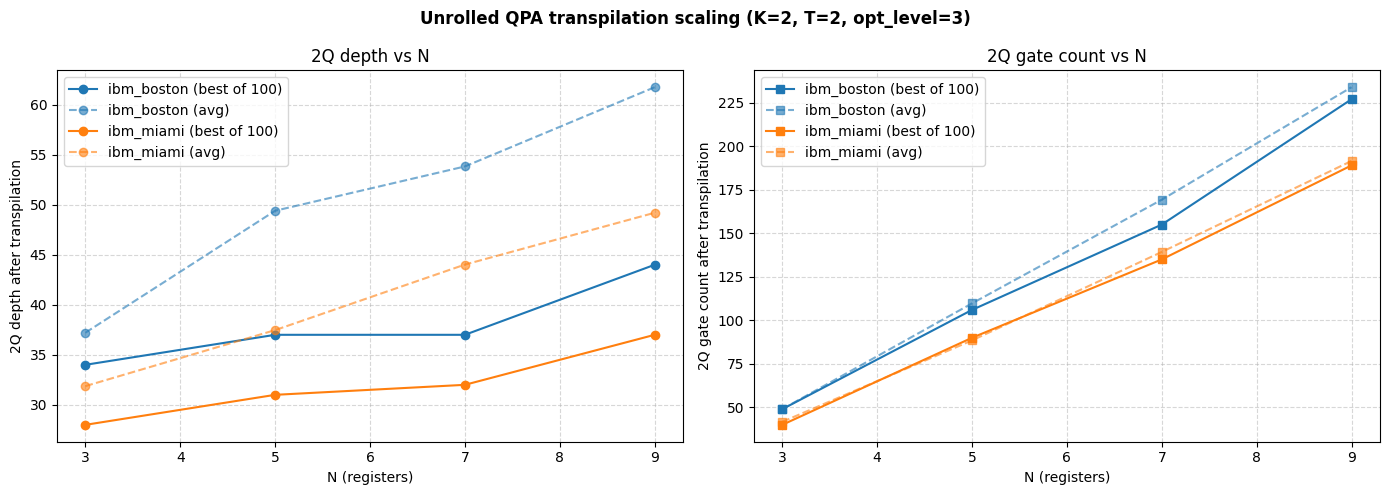

In [8]:
with open(JSON_PATH) as f:
    disk_results = json.load(f)

df = pd.DataFrame(disk_results)
df = df[df["best_2q_depth"].notna()]

colors = {"ibm_boston": "#1f77b4", "ibm_miami": "#ff7f0e"}

fig, (ax_d, ax_g) = plt.subplots(1, 2, figsize=(14, 5))

for backend_name in BACKENDS:
    sub = df[df["backend"] == backend_name].sort_values("n")
    if sub.empty:
        continue
    c = colors.get(backend_name, None)
    ax_d.plot(sub["n"], sub["best_2q_depth"], marker="o", color=c, label=f"{backend_name} (best of {N_SEEDS})")
    ax_d.plot(sub["n"], sub["avg_2q_depth"], marker="o", color=c, linestyle="--", alpha=0.6, label=f"{backend_name} (avg)")
    ax_g.plot(sub["n"], sub["best_2q_gates"], marker="s", color=c, label=f"{backend_name} (best of {N_SEEDS})")
    ax_g.plot(sub["n"], sub["avg_2q_gates"], marker="s", color=c, linestyle="--", alpha=0.6, label=f"{backend_name} (avg)")

ax_d.set_xlabel("N (registers)")
ax_d.set_ylabel("2Q depth after transpilation")
ax_d.set_title("2Q depth vs N")
ax_d.grid(True, linestyle="--", alpha=0.5)
ax_d.legend()

ax_g.set_xlabel("N (registers)")
ax_g.set_ylabel("2Q gate count after transpilation")
ax_g.set_title("2Q gate count vs N")
ax_g.grid(True, linestyle="--", alpha=0.5)
ax_g.legend()

fig.suptitle(f"Unrolled QPA transpilation scaling (K={K}, T={T}, opt_level={OPT_LEVEL})", fontweight="bold")
plt.tight_layout()

plot_path = RESULTS_DIR / f"scaling_plot_T{T}.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
print(f"Saved plot to {plot_path}")
plt.show()